In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import h3
import pandas as pd
import numpy as np
import os
from pathlib import Path
import geopandas as gpd
import contextily as ctx
import io, zipfile, requests
import shapely

import folium
import mapclassify
from shapely.geometry import Polygon

## 0 Load data
Census tract information is missing for approximately half of the observations. Therefore, analyses based on census tracts are performed on a reduced dataset containing only trips with available census tract information, whereas community area and H3 analyses use the complete dataset.

In [2]:
taxi_trips = pd.read_parquet("../data/processed/taxi_data_processed_big.parquet")
taxi_trips_cen = pd.read_parquet("../data/processed/taxi_data_processed_small.parquet")
pois_h3_7 = pd.read_csv("../data/processed/chicago_pois_agg_7.csv")

taxi_trips.info()

<class 'pandas.DataFrame'>
Index: 12949755 entries, 419224 to 16086254
Data columns (total 22 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Trip ID                     str           
 1   Taxi ID                     str           
 2   Trip Start Timestamp        datetime64[us]
 3   Trip End Timestamp          datetime64[us]
 4   Trip Seconds                float64       
 5   Trip Miles                  float64       
 6   Pickup Census Tract         float64       
 7   Dropoff Census Tract        float64       
 8   Pickup Community Area       float64       
 9   Dropoff Community Area      float64       
 10  Trip Total                  float64       
 11  Company                     str           
 12  Pickup Centroid Latitude    float64       
 13  Pickup Centroid Longitude   float64       
 14  Dropoff Centroid Latitude   float64       
 15  Dropoff Centroid Longitude  float64       
 16  h3_index_pickup_7          

In [3]:
# Chicago community area boundaries — download from the city data portal and cache locally
CA_PATH = Path('..') / 'data' / 'chicago_community_areas.gpkg'

if CA_PATH.exists():
    community_areas = gpd.read_file(CA_PATH)
else:
    print('Downloading Chicago community area boundaries...')
    url = 'https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=100'
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    community_areas = gpd.read_file(io.BytesIO(r.content))
    community_areas.to_file(CA_PATH, driver='GPKG')
    print(f'Saved {len(community_areas)} community areas to {CA_PATH}')

community_areas = community_areas.to_crs(epsg=4326)
print(f'Community areas loaded: {len(community_areas)}')

Community areas loaded: 77


In [4]:
community_areas["area_numbe"] = pd.to_numeric(
    community_areas["area_numbe"],
    errors="coerce"
)

KeyError: 'area_numbe'

## 1 Spatial Resolution & Data Quality

### 1.1 Spatial entities overview

This section introduces the spatial units used throughout the project and highlights their different spatial granularity.

The taxi dataset provides two administrative location levels:

- **Community Areas**, representing relatively coarse administrative regions in Chicago.
- **Census Tracts**, providing a much finer spatial resolution.

In addition, three H3 hexagonal grids (resolutions 7–9) were generated from the provided pickup coordinates.

| Level | Source | Note |
|---|---|---|
| Centroid coordinates (lat/lon) | raw column | privacy-masked centroids, *not* GPS points |
| Census tract | raw column | suppressed by the data portal for privacy in some rows |
| Community area (CA) | raw column | 77 official Chicago community areas |
| H3 hexagons (res 7 & 8) | derived from the centroid coordinates | used by our downstream pipeline |

The Chicago Data Portal masks trip locations: when the census tract may be disclosed, the
coordinates are the **tract centroid**; otherwise they fall back to the **community-area
centroid**.

In [ ]:
pickup_spatial_units = {
    "community_area": "Pickup Community Area",
    "census_tract": "Pickup Census Tract",
    "h3_7": "h3_index_pickup_7",
    "h3_8": "h3_index_pickup_8",
    "h3_9": "h3_index_pickup_9"
}

dropoff_spatial_units = {
    "Community Area": "Dropoff Community Area",
    "Census Tract": "Dropoff Census Tract",
    "H3 Resolution 8": "h3_index_dropoff_8"
}

In [ ]:
overview = []

for name, column in pickup_spatial_units.items():
    overview.append({
        "Spatial Unit": name,
        "Unique Units": taxi_trips[column].nunique(dropna=True),
        "Missing Values": taxi_trips[column].isna().sum(),
        "Coverage (%)": round(
            100 * (1 - taxi_trips[column].isna().mean()), 2
        ),
    })

overview_df = pd.DataFrame(overview)

overview_df

,Spatial Unit,Unique Units,Missing Values,Coverage (%)
0,community_area,77,0,100.00
1,census_tract,602,7659353,47.16
2,h3_7,124,0,100.00
3,h3_8,470,0,100.00
4,h3_9,664,0,100.00


In [ ]:
(
    taxi_trips[["Pickup Census Tract", "h3_index_pickup_9"]]
    .drop_duplicates()
    .groupby("h3_index_pickup_9")
    .size()
    .describe()
)

count    664.000000
mean       1.022590
std        0.148706
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
dtype: float64

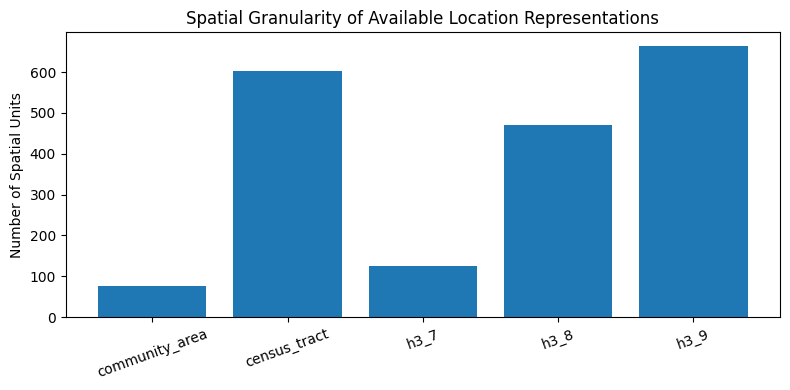

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

bars = ax.bar(
    overview_df["Spatial Unit"],
    overview_df["Unique Units"]
)

ax.set_ylabel("Number of Spatial Units")
ax.set_title("Spatial Granularity of Available Location Representations")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The number of spatial units decreases from 664 H3-9 cells to 602 census tracts, 470 H3-8 cells, 124 H3-7 cells and 77 community areas. Due to privacy protection, pickup coordinates are mapped to census tract centroids if available, else community area centroid. Consequently, the H3 discretization does not provide additional spatial detail. Instead, it creates alternative aggregation levels that allow the study of spatial smoothing and aggregation effects.

### 1.2 Missingness per location level

In [ ]:
levels_cols = {
    "Coordinates": (
        "Pickup Centroid Latitude",
        "Dropoff Centroid Latitude",
    ),
    "Community Area": (
        "Pickup Community Area",
        "Dropoff Community Area",
    ),
    "Census Tract": (
        "Pickup Census Tract",
        "Dropoff Census Tract",
    ),
    "H3 Resolution 7": (
        "h3_index_pickup_7",
        "h3_index_dropoff_7",
    ),
    "H3 Resolution 8": (
        "h3_index_pickup_8",
        "h3_index_dropoff_8",
    ),
    "H3 Resolution 9": (
        "h3_index_pickup_9",
        "h3_index_dropoff_9",
    ),
}

missingness = pd.DataFrame(
    [
        {
            "Spatial Level": level,
            "Missing Pickup": taxi_trips[pickup].isna().sum(),
            "Missing Pickup (%)": round(
                100 * taxi_trips[pickup].isna().mean(), 2
            ),
            "Missing Dropoff": taxi_trips[dropoff].isna().sum(),
            "Missing Dropoff (%)": round(
                100 * taxi_trips[dropoff].isna().mean(), 2
            ),
        }
        for level, (pickup, dropoff) in levels_cols.items()
    ]
)

missingness

,Spatial Level,Missing Pickup,Missing Pickup (%),Missing Dropoff,Missing Dropoff (%)
0,Coordinates,0,0.00,0,0.00
1,Community Area,0,0.00,0,0.00
2,Census Tract,7659353,52.84,7659353,52.84
3,H3 Resolution 7,0,0.00,0,0.00
4,H3 Resolution 8,0,0.00,0,0.00
5,H3 Resolution 9,0,0.00,0,0.00


### 1.3 Coordinate Privacy and Effective Precision

Due tue the privacy protection many trips share identical coordinate pairs. While H3 indices are computed at different resolutions, their effective spatial precision is limited by the underlying anonymized coordinates rather than by the H3 grid itself. This effect is particularly important for finer H3 resolutions, where multiple trips may still originate from the same centroid location.

In [ ]:
community_centroids = (
    taxi_trips[
        [
            "Pickup Community Area",
            "Pickup Centroid Latitude",
            "Pickup Centroid Longitude",
        ]
    ]
    .dropna()
    .drop_duplicates()
)

In [ ]:
pairs = (
    taxi_trips[
        [
            "Pickup Centroid Latitude",
            "Pickup Centroid Longitude",
        ]
    ]
    .dropna()
    .drop_duplicates()
    .rename(
        columns={
            "Pickup Centroid Latitude": "lat",
            "Pickup Centroid Longitude": "lng",
        }
    )
)

masked_coords = set(
    zip(
        community_centroids["Pickup Centroid Latitude"],
        community_centroids["Pickup Centroid Longitude"],
    )
)

pairs["Coordinate Type"] = [
    "Community Area Centroid"
    if (lat, lng) in masked_coords
    else "Census Tract Centroid"
    for lat, lng in zip(pairs["lat"], pairs["lng"])
]

In [ ]:
pairs_gdf = gpd.GeoDataFrame(
    pairs,
    geometry=gpd.points_from_xy(
        pairs["lng"],
        pairs["lat"]
    ),
    crs="EPSG:4326"
)

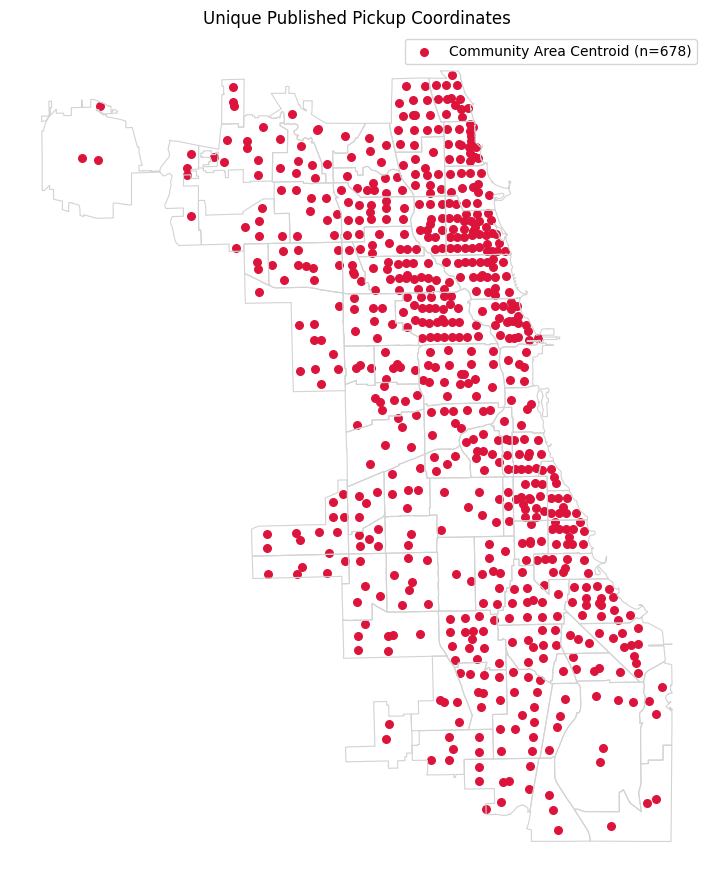

In [ ]:
fig, ax = plt.subplots(figsize=(8, 9))

community_areas.boundary.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.8
)

colors = {
    "Census Tract Centroid": "steelblue",
    "Community Area Centroid": "crimson",
}

sizes = {"Census Tract Centroid": 5, "Community Area Centroid": 30}

for coord_type in pairs_gdf["Coordinate Type"].unique():

    subset = pairs_gdf[
        pairs_gdf["Coordinate Type"] == coord_type
    ]

    subset.plot(
        ax=ax,
        color=colors[coord_type],
        markersize=sizes[coord_type],
        label=f"{coord_type} (n={len(subset)})",
    )

ax.set_title("Unique Published Pickup Coordinates")
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 1.4 Consistency between location levels

Before comparing different spatial resolutions, we verify that the spatial representations are internally consistent.

The checks below evaluate whether administrative units, published coordinates, and derived H3 indices form a coherent hierarchy. They also quantify how much spatial detail is lost when aggregating census tracts into coarser H3 resolutions.

In [ ]:
# Combine pickup and dropoff locations into one table

locations = pd.concat(
    [
        taxi_trips[
            [
                "Pickup Census Tract",
                "Pickup Community Area",
                "Pickup Centroid Latitude",
                "Pickup Centroid Longitude",
                "h3_index_pickup_7",
                "h3_index_pickup_8",
                "h3_index_pickup_9",
            ]
        ].set_axis(
            ["tract", "community", "lat", "lon", "h3_7", "h3_8", "h3_9"],
            axis=1,
        ),
        taxi_trips[
            [
                "Dropoff Census Tract",
                "Dropoff Community Area",
                "Dropoff Centroid Latitude",
                "Dropoff Centroid Longitude",
                "h3_index_dropoff_7",
                "h3_index_dropoff_8",
                "h3_index_dropoff_9",
            ]
        ].set_axis(
            ["tract", "community", "lat", "lon", "h3_7", "h3_8", "h3_9"],
            axis=1,
        ),
    ],
    ignore_index=True,
).drop_duplicates()

In [ ]:
# 1. Census tract -> Community Area
tract_to_ca = (
    locations
    .dropna(subset=["tract", "community"])
    .groupby("tract")["community"]
    .nunique()
)

# 2. Census tract -> Published coordinates
tract_to_coord = (
    locations
    .dropna(subset=["tract", "lat", "lon"])
    .groupby("tract")[["lat", "lon"]]
    .nunique()["lat"]
)

# 3. Census tracts per H3 cell
tracts_per_h37 = (
    locations
    .dropna(subset=["tract"])
    .groupby("h3_7")["tract"]
    .nunique()
)
tracts_per_h38 = (
    locations
    .dropna(subset=["tract"])
    .groupby("h3_8")["tract"]
    .nunique()
)
tracts_per_h39 = (
    locations
    .dropna(subset=["tract"])
    .groupby("h3_9")["tract"]
    .nunique()
)

# 4. H3 cells per Community Area
h37_per_ca = (
    locations
    .dropna(subset=["community"])
    .groupby("community")["h3_7"]
    .nunique()
)
h38_per_ca = (
    locations
    .dropna(subset=["community"])
    .groupby("community")["h3_8"]
    .nunique()
)
h39_per_ca = (
    locations
    .dropna(subset=["community"])
    .groupby("community")["h3_9"]
    .nunique()
)

In [ ]:
consistency = pd.DataFrame([
        {"Check": "Tracts mapped to multiple community areas", "Value": (tract_to_ca > 1).sum(),},
        {"Check": "Tracts with multiple published coordinates", "Value": (tract_to_coord > 1).sum(),},
        {"Check": "Mean tracts per occupied H3-7 cell", "Value": round(tracts_per_h37.mean(), 2),},
        {"Check": "Mean tracts per occupied H3-8 cell", "Value": round(tracts_per_h38.mean(), 2),},
        {"Check": "Mean tracts per occupied H3-9 cell", "Value": round(tracts_per_h39.mean(), 2),},
        {"Check": "Mean occupied H3-7 cells per community area", "Value": round(h37_per_ca.mean(), 2),},
        {"Check": "Mean occupied H3-8 cells per community area", "Value": round(h38_per_ca.mean(), 2),},
        {"Check": "Mean occupied H3-9 cells per community area", "Value": round(h39_per_ca.mean(), 2),},
    ])

consistency

,Check,Value
0,Tracts mapped to multiple community areas,0.00
1,Tracts with multiple published coordinates,0.00
2,Mean tracts per occupied H3-7 cell,5.45
3,Mean tracts per occupied H3-8 cell,1.40
4,Mean tracts per occupied H3-9 cell,1.01
5,Mean occupied H3-7 cells per community area,3.10
6,Mean occupied H3-8 cells per community area,7.06
7,Mean occupied H3-9 cells per community area,9.56


The consistency checks confirm that the different spatial representations are internally coherent.

Each census tract maps to exactly one community area, and each census tract is represented by a single published coordinate pair. This indicates that the anonymized coordinates consistently correspond to tract or community-area centroids.

The relationship between census tracts and H3 cells depends strongly on the H3 resolution. At resolution 7, an occupied H3 cell contains on average **5.45 census tract centroids**, indicating substantial spatial aggregation. At resolution 8, this value decreases to **1.40**, while at resolution 9 almost every occupied H3 cell corresponds to a single census tract centroid (**1.01** on average).

Similarly, the average number of occupied H3 cells within a community area increases from **3.10** (resolution 7) to **7.06** (resolution 8) and **9.56** (resolution 9), reflecting the increasing spatial granularity of the H3 grid.

## 2 Descriptive Spatial Patterns

This section explores the spatial distribution of taxi activity across Chicago. We first examine the geographical distribution of pickup demand at different spatial resolutions to identify areas with high transportation demand. Afterwards, spatial patterns of average trip characteristics, including trip length and trip price, are analysed to investigate whether travel behaviour differs across locations.

Unless stated otherwise, comparisons involving census tracts are based on the subset of trips with available census tract identifiers (`taxi_trips_cen`). Community areas and H3 grids are derived from the full dataset where possible.

### 2.1 Spatial Demand Distribution

The following figure compares pickup demand across four spatial representations: community areas, census tracts, H3 resolution 7, and H3 resolution 8. To ensure a fair comparison across spatial resolutions, all maps are based on the subset of trips with available census tract identifiers (`taxi_trips_cen`).

A logarithmic colour scale is used because pickup demand is highly concentrated in relatively few locations, while many spatial units contain comparatively few trips.


In [ ]:
# Pickup demand per spatial unit

community_counts = (
    taxi_trips_cen
    .groupby("Pickup Community Area")
    .size()
)

tract_counts = (
    taxi_trips_cen
    .groupby("Pickup Census Tract")
    .size()
)

h3_7_counts = (
    taxi_trips_cen
    .groupby("h3_index_pickup_7")
    .size()
)

h3_8_counts = (
    taxi_trips_cen
    .groupby("h3_index_pickup_8")
    .size()
)

In [ ]:
# prepare hexagons
def build_h3_gdf(counts):
    return gpd.GeoDataFrame(
        {"pickups": counts.values},
        geometry=[Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
                  for cell in counts.index],
        crs="EPSG:4326",
    )

h3_7_plot = build_h3_gdf(h3_7_counts)
h3_8_plot = build_h3_gdf(h3_8_counts)

In [ ]:
#prepare community areas
community_plot = community_areas.copy()

community_plot = community_plot.merge(

    community_counts.rename("pickups"),
    left_on="area_numbe",
    right_index=True,
    how="left"
)

In [ ]:
#prepare Census tracts
tract_points = (
    taxi_trips_cen[["Pickup Census Tract", "Pickup Centroid Latitude", "Pickup Centroid Longitude"]]
    .dropna()
    .drop_duplicates("Pickup Census Tract")
    .set_index("Pickup Census Tract")
)

tract_plot = tract_points.join(
    tract_counts.rename("pickups"),
    how="inner"
)

C:\Users\Larissa\AppData\Local\Temp\ipykernel_10540\4241349810.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.75, 1])


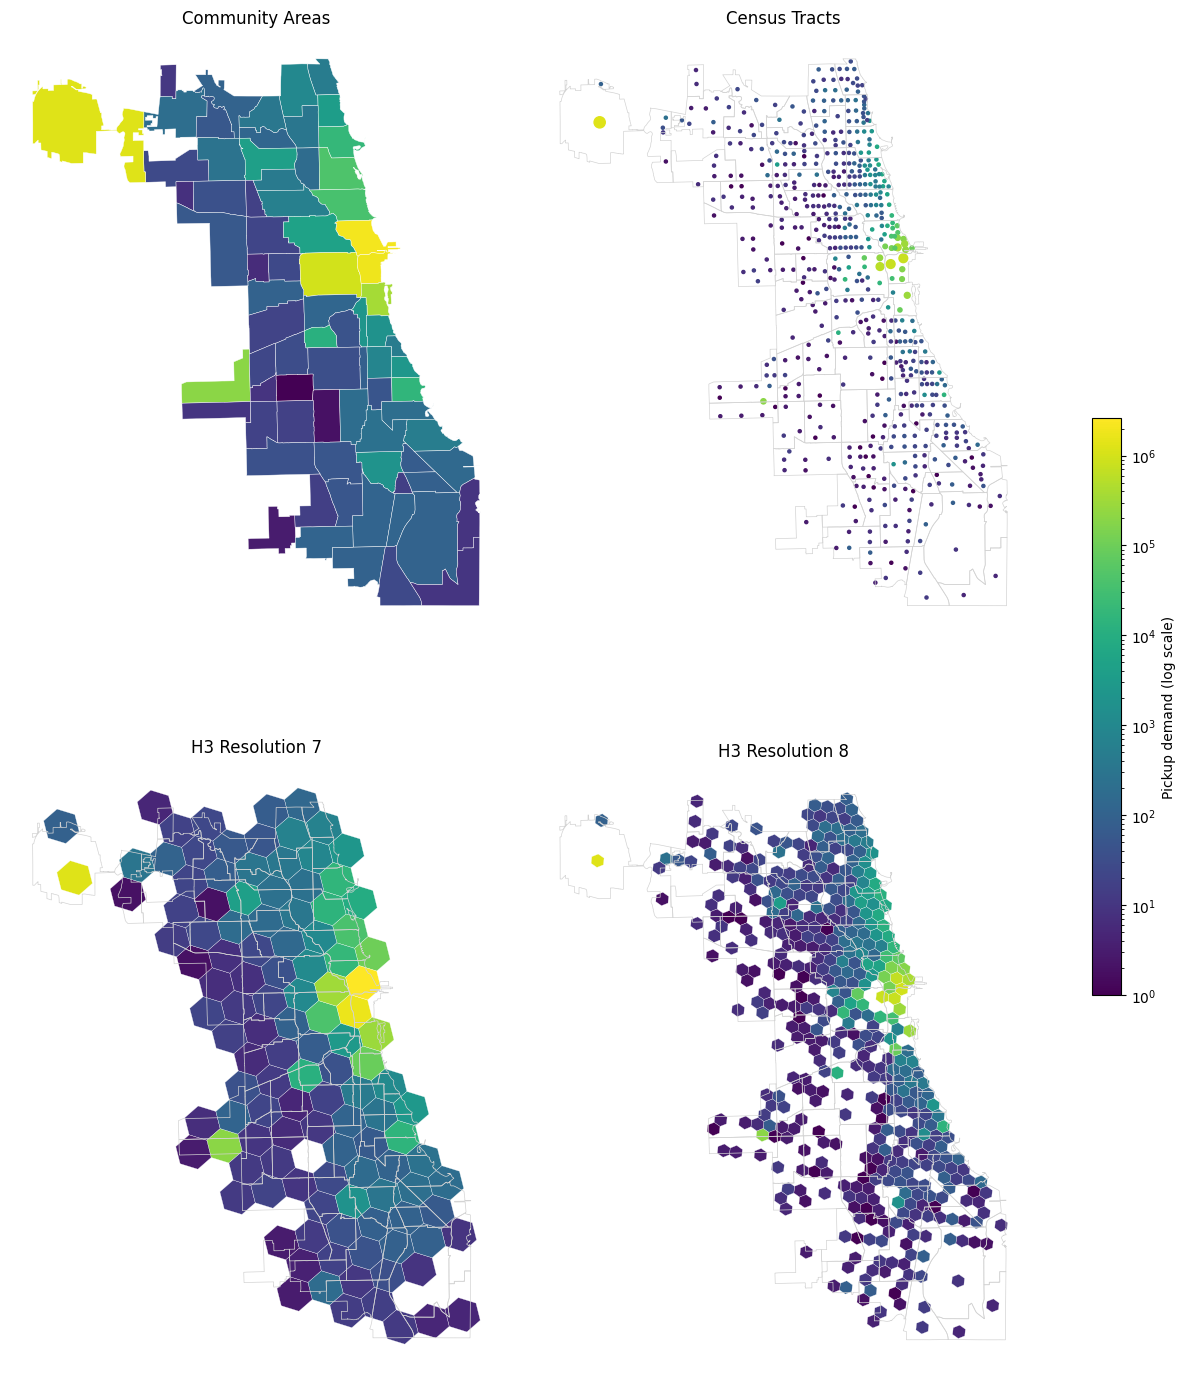

In [ ]:
# creating maps

fig, axes = plt.subplots(2, 2, figsize=(14, 15))

norm = mcolors.LogNorm(
    vmin=1,
    vmax=max(
        community_counts.max(),
        tract_counts.max(),
        h3_7_counts.max(),
        h3_8_counts.max()
    ))

community_plot.plot(column="pickups", ax=axes[0,0], cmap="viridis", norm=norm, edgecolor="white", linewidth=0.3)
axes[0,0].set_title("Community Areas")

community_areas.boundary.plot(ax=axes[0,1], color="lightgray", linewidth=0.5)
axes[0,1].scatter(
    tract_plot["Pickup Centroid Longitude"],
    tract_plot["Pickup Centroid Latitude"],
    s=5 + 60 * tract_plot["pickups"] / tract_plot["pickups"].max(),
    c=tract_plot["pickups"],
    cmap="viridis",
    norm=norm
)
axes[0,1].set_title("Census Tracts")

community_areas.boundary.plot(ax=axes[1,0], color="lightgray", linewidth=0.5)
h3_7_plot.plot(
    column="pickups",
    cmap="viridis",
    norm=norm,
    edgecolor="white",
    linewidth=0.2,
    ax=axes[1,0]
)
axes[1,0].set_title("H3 Resolution 7")

community_areas.boundary.plot(ax=axes[1,1], color="lightgray", linewidth=0.5)
h3_8_plot.plot(
    column="pickups",
    cmap="viridis",
    norm=norm,
    edgecolor="white",
    linewidth=0.2,
    ax=axes[1,1]
)
axes[1,1].set_title("H3 Resolution 8")
for ax in axes.ravel():
    ax.set_axis_off()

fig.colorbar(
    plt.cm.ScalarMappable(
        norm=norm,
        cmap="viridis"
    ),
    ax=axes,
    shrink=0.5,
    label="Pickup demand (log scale)"
)

fig.tight_layout(rect=[0, 0, 0.75, 1])
fig.savefig("../docs/maps/spatial_demand_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The spatial distribution of pickup demand is highly concentrated rather than uniformly distributed across Chicago. All spatial representations consistently identify the central business district as the primary demand hotspot, while secondary concentrations are visible near O'Hare International Airport and along the densely populated lakefront.

Increasing the spatial resolution reveals progressively finer spatial structures. Community areas provide a coarse overview of demand but smooth substantial local variation. In contrast, census tracts and H3 grids expose smaller demand hotspots that are aggregated within larger administrative regions.

The H3 representations contain unoccupied cells because the published pickup coordinates correspond to privacy-preserving centroids rather than the true pickup locations. Consequently, only H3 cells containing one of the released centroids are populated.

### 2.2 Spatial Distribution of Trip Characteristics

While the previous section focused on where taxi demand occurs, this section investigates whether trip characteristics also vary spatially. Average trip length and average trip price are aggregated at H3 resolution 7, as it provides a good compromise between spatial detail and statistical robustness.

Only the H3 resolution is considered here, as the objective is to identify spatial patterns in trip characteristics rather than compare spatial representations.

In [ ]:
#Spatial aggregation

def create_spatial_statistics(df, group_column):

    return (
        df.groupby(group_column)
        .agg(
            trip_count=("Trip ID", "count"),
            avg_trip_length=("Trip Miles", "mean"),
            avg_trip_duration=("Trip Seconds", "mean"),
            avg_price=("Trip Total", "mean"),
        )
        .reset_index()
    )

In [ ]:
#create statistics
h3_stats = create_spatial_statistics(taxi_trips,"h3_index_pickup_7")
#h3_stats = h3_stats[h3_stats["trip_count"] >= 5]

In [ ]:
def build_h3_geodataframe(df, h3_column):

    gdf = df.copy()

    gdf["geometry"] = [
        Polygon(
            [(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
        for cell in gdf[h3_column]
    ]

    return gpd.GeoDataFrame(
        gdf,
        geometry="geometry",
        crs="EPSG:4326",
    )

In [ ]:
h3_trip_characteristics = build_h3_geodataframe(h3_stats, "h3_index_pickup_7")

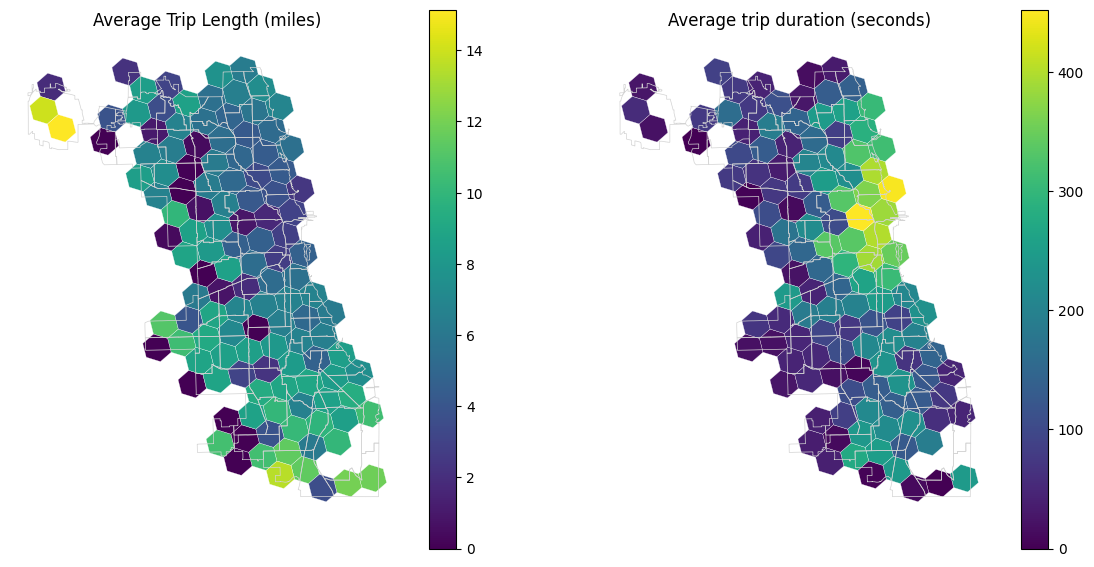

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,7))

community_areas.boundary.plot(ax=axes[0], color="lightgray", linewidth=0.5)

h3_trip_characteristics.plot(
    column="avg_trip_length",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axes[0]
)

axes[0].set_title("Average Trip Length (miles)")
axes[0].set_axis_off()

community_areas.boundary.plot(ax=axes[1], color="lightgray", linewidth=0.5)

h3_trip_characteristics.plot(
    column="avg_trip_duration",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axes[1]
)

axes[1].set_title("Average trip duration (seconds)")
axes[1].set_axis_off()

Average trip characteristics exhibit clear spatial variation across Chicago. Average trip lengths tend to increase towards the city boundaries and around airport areas, reflecting longer journeys originating from or terminating in peripheral locations.

Average trip duration follows a different spatial pattern. The longest average travel times are observed in and around the central business district, where higher traffic density and congestion are expected. Consequently, spatial patterns in trip duration are not solely explained by travel distance.

## 3 Comparison of Spatial Resolutions

### 3.1 Overview

This table summarises the basic characteristics of the four spatial representations considered in this study. As spatial resolution increases, the number of spatial units grows substantially, resulting in fewer observations per unit and greater variability in local demand.

These descriptive statistics provide a first indication of the trade-off between spatial detail and statistical stability, which is examined in more detail in the following sections on spatial concentration and sparsity.

In [ ]:
spatial_counts = {
    "Community Areas": community_counts,
    "Census Tracts": tract_counts,
    "H3 Resolution 7": h3_7_counts,
    "H3 Resolution 8": h3_8_counts,
}

In [ ]:
summary = pd.DataFrame()

total_trips = len(taxi_trips_cen)

for level, counts in spatial_counts.items():

    summary.loc[level, "Number of regions"] = len(counts)
    summary.loc[level, "Mean demand"] = counts.mean()
    summary.loc[level, "Median demand"] = counts.median()
    summary.loc[level, "Std. demand"] = counts.std()
    summary.loc[level, "Coefficient of variation"] = (
        counts.std() / counts.mean()
    )

summary = summary.round(2)
summary

,Number of regions,Mean demand,Median demand,Std. demand,Coefficient of variation
Community Areas,77.0,88772.09,109.0,355659.26,4.01
Census Tracts,602.0,11354.57,15.0,79365.52,6.99
H3 Resolution 7,121.0,56491.33,64.0,308884.14,5.47
H3 Resolution 8,443.0,15429.91,16.0,103723.57,6.72


For all spatial representations, the median demand is considerably lower than the corresponding mean demand, indicating a highly right-skewed distribution in which a small number of locations account for a disproportionately large share of all taxi pickups. This skewness is reflected by the high coefficients of variation across all resolutions, with the finest spatial representations (census tracts and H3 resolution 8) exhibiting the greatest relative variability.

These descriptive statistics provide an initial overview of the demand distribution. The following sections investigate this behaviour in more detail by examining the spatial concentration of demand and the degree of spatial sparsity across the different spatial resolutions.

### 3.2 Spatial Concentration

Spatial concentration describes the extent to which taxi demand is concentrated in a small number of spatial units. Higher concentration indicates that relatively few regions account for a large proportion of all pickups, whereas lower concentration implies a more even spatial distribution.

To compare the different spatial representations, the share of trips contained in the single largest region and in the five largest regions is reported. In addition, Lorenz curves visualize the cumulative distribution of pickup demand across spatial units.

In [ ]:
for name, col in pickup_spatial_units.items():

    counts = taxi_trips[col].value_counts()

    print(f"\n{name}")
    print("-" * 40)
    print(f"Number of regions: {counts.size}")
    print(f"Largest region: {counts.iloc[0]:,} trips ({counts.iloc[0]/len(taxi_trips):.2%})")
    print(f"Top 5 regions: {counts.head(5).sum()/len(taxi_trips):.2%} of all trips")
    print(f"Median trips per region: {counts.median():,.0f}")


community_area
----------------------------------------
Number of regions: 77
Largest region: 3,517,801 trips (24.27%)
Top 5 regions: 73.58% of all trips
Median trips per region: 24,239

census_tract
----------------------------------------
Number of regions: 602
Largest region: 1,305,840 trips (9.01%)
Top 5 regions: 26.24% of all trips
Median trips per region: 15

h3_7
----------------------------------------
Number of regions: 124
Largest region: 4,161,576 trips (28.71%)
Top 5 regions: 66.78% of all trips
Median trips per region: 10,487

h3_8
----------------------------------------
Number of regions: 470
Largest region: 1,662,314 trips (11.47%)
Top 5 regions: 45.33% of all trips
Median trips per region: 26

h3_9
----------------------------------------
Number of regions: 664
Largest region: 1,548,407 trips (10.68%)
Top 5 regions: 37.94% of all trips
Median trips per region: 20


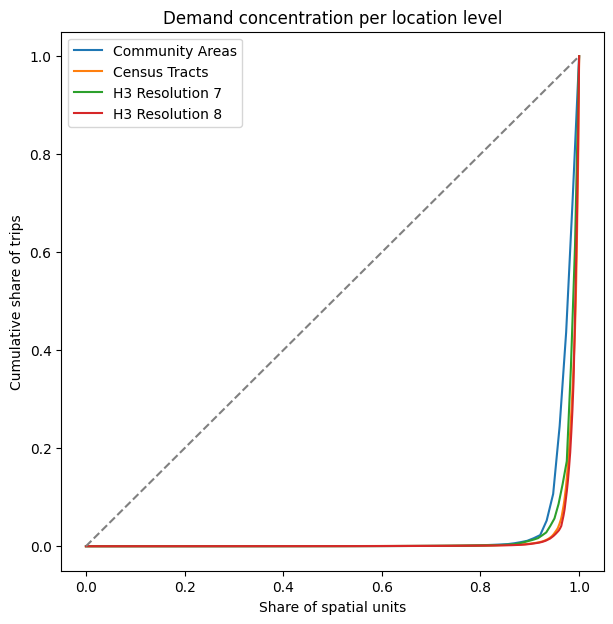

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

for level, counts in spatial_counts.items():

    x = np.linspace(0, 1, len(counts))
    y = np.cumsum(np.sort(counts.values))
    y = y / y[-1]
    ax.plot(x, y, label=level)

ax.plot([0,1],[0,1], "--", color="gray")
ax.set_xlabel("Share of spatial units")
ax.set_ylabel("Cumulative share of trips")
ax.set_title("Demand concentration per location level")
ax.legend()
plt.show()

Taxi demand is highly concentrated in a small number of spatial units. Independent of the chosen spatial resolution, only a few regions account for the majority of all trips. The strongest concentration is observed for Community Areas and H3 resolution 7, while the demand distribution becomes more balanced for finer spatial resolutions such as Census Tracts and H3 resolutions 8 and 9.

The Lorenz curves illustrate this behaviour visually. Curves further away from the diagonal indicate stronger concentration, confirming that coarser spatial aggregations concentrate demand into fewer regions, whereas finer spatial resolutions distribute demand more evenly across space.

### 3.3 Spatial Sparsity

Increasing the spatial resolution results in a larger number of spatio-temporal cells, many of which contain no observations. This sparsity can reduce the statistical reliability of downstream analyses and predictive models.

The table below therefore compares the coverage of the unit-hour grid across the different spatial representations. For each spatial resolution, the table reports the proportion of empty space-time cells, the typical temporal activity of each region, and the average number of pickups observed in non-empty cells.

In [ ]:
taxi_trips["start_hour"] = pd.to_datetime(
    taxi_trips["Trip Start Timestamp"], format="%m/%d/%Y %I:%M:%S %p"
).dt.floor("h")

In [ ]:
# Time span covered by the data
n_hours = (
    int(
        (taxi_trips["start_hour"].max() - taxi_trips["start_hour"].min())
        / pd.Timedelta("1h")
    )
    + 1
)

coverage_rows = []

for name, col in pickup_spatial_units.items():

    sub = taxi_trips[[col, "start_hour"]].dropna()

    active_hours = (
        sub.groupby(col, observed=True)["start_hour"]
        .nunique()
    )

    n_units = len(active_hours)
    total_cells = n_units * n_hours
    non_empty_cells = active_hours.sum()

    coverage_rows.append({
        "Spatial resolution": name,
        "Number of regions": n_units,
        "Unit-hour cells": total_cells,
        "Non-empty cells": non_empty_cells,
        "Empty cells (%)": 100 * (1 - non_empty_cells / total_cells),
        "Median active hours / region": active_hours.median(),
        "Mean pickups / non-empty cell": len(sub) / non_empty_cells,
    })

coverage = (
    pd.DataFrame(coverage_rows)
    .set_index("Spatial resolution")
    .round({
        "Empty cells (%)": 1,
        "Median active hours / region": 0,
        "Mean pickups / non-empty cell": 2,
    })
)

coverage


,Number of regions,Unit-hour cells,Non-empty cells,Empty cells (%),Median active hours / region,Mean pickups / non-empty cell
Spatial resolution,,,,,,
community_area,77,1630013,925617,43.2,12561.0,15.66
census_tract,602,12743738,417315,96.7,8.0,16.38
h3_7,124,2624956,954063,63.7,6878.0,15.19
h3_8,470,9949430,1209215,87.8,14.0,11.99
h3_9,664,14056216,1322981,90.6,11.0,10.96


The table highlights the increasing sparsity of the spatio-temporal data as the spatial resolution becomes finer. While only 43.2% of all community area-hour cells are empty, this proportion rises to 63.7% for H3 resolution 7, 87.8% for H3 resolution 8, and exceeds 90% for H3 resolution 9. Census tracts exhibit a similarly high level of sparsity, with 96.7% of all tract-hour combinations containing no trips.

The median number of active hours per region decreases substantially with finer spatial resolutions. Community areas are active during most hours of the observation period, whereas a typical census tract or H3 resolution 8 cell records trips during only a small fraction of all hours. This indicates that taxi demand becomes increasingly fragmented across space and time.

In contrast, the average number of pickups within non-empty cells remains relatively stable across most spatial resolutions. This suggests that the main consequence of increasing spatial resolution is not a reduction in demand where activity exists, but a rapidly growing number of empty spatio-temporal cells. Such sparsity should be considered when selecting an appropriate spatial resolution for further descriptive analyses and predictive modelling.

## 4 Spatial Hotspot Detection

Hotspot detection is performed on the H3 resolution 7 grid. Compared with finer spatial resolutions, H3 resolution 7 provides a better balance between spatial detail and statistical robustness by reducing the sparsity of the underlying demand data.

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

### 4.1 Gaussian Mixture Model

In [ ]:
hotspot_gdf = h3_trip_characteristics.copy()

hotspot_gdf["centroid"] = hotspot_gdf.geometry.centroid

hotspot_gdf["x"] = hotspot_gdf.centroid.x
hotspot_gdf["y"] = hotspot_gdf.centroid.y

C:\Users\Larissa\AppData\Local\Temp\ipykernel_10540\1443932469.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["centroid"] = hotspot_gdf.geometry.centroid
C:\Users\Larissa\AppData\Local\Temp\ipykernel_10540\1443932469.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["x"] = hotspot_gdf.centroid.x
C:\Users\Larissa\AppData\Local\Temp\ipykernel_10540\1443932469.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["y"] = hotspot_gdf.centroid.y


In [ ]:
coords = []

for _, row in hotspot_gdf.iterrows():
    n = max(1, round(row["trip_count"] / 100))
    coords.extend([[row["x"], row["y"]]] * n)

coords = np.asarray(coords)

Since the Gaussian Mixture Model implementation does not support sample weights, cell centroids were replicated proportionally to their pickup demand (one sample per 100 trips) to approximate a weighted clustering while keeping the computational effort manageable.

In [ ]:
bic_scores = []

component_range = range(2, 15)

for n_components in component_range:

    model = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=42,
    )

    model.fit(coords)

    bic_scores.append(model.bic(coords))

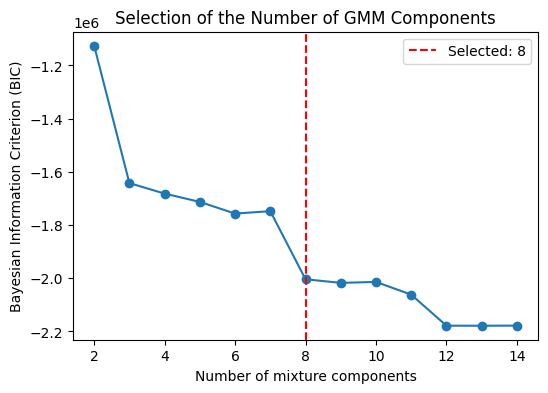

In [ ]:
chosen_k = 8

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(component_range, bic_scores, marker="o")
ax.axvline(
    chosen_k,
    color="red",
    linestyle="--",
    label=f"Selected: {chosen_k}"
)

ax.set_xlabel("Number of mixture components")
ax.set_ylabel("Bayesian Information Criterion (BIC)")
ax.set_title("Selection of the Number of GMM Components")
ax.legend()

plt.show()

Although the BIC continued to decrease for larger numbers of mixture components, the most pronounced improvement occurred up to eight components. Since the objective of the analysis is the identification of interpretable spatial hotspots rather than density estimation, eight components were selected as a compromise between model fit and interpretability.

In [ ]:
#fit final model
gmm = GaussianMixture(
    n_components=chosen_k,
    covariance_type="full",
    random_state=42,
)

gmm.fit(coords)

hotspot_gdf["cluster"] = gmm.predict(
    hotspot_gdf[["x", "y"]]
)

c:\Users\Larissa\AaA\AAA_Project_SoSe26\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


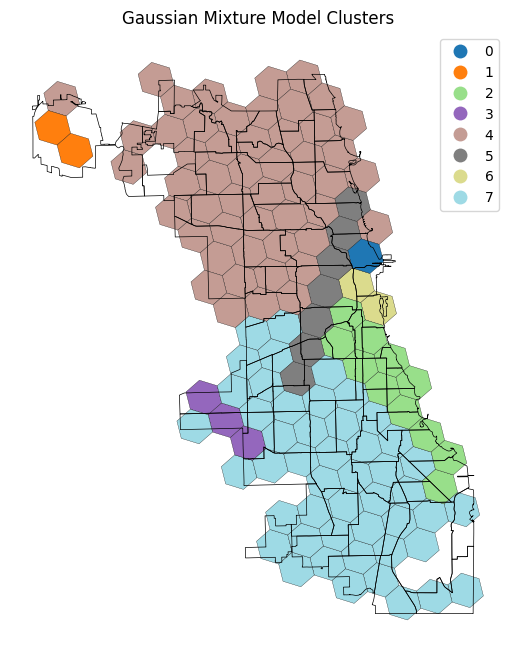

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

hotspot_gdf.plot(
    column="cluster",
    categorical=True,
    legend=True,
    cmap="tab20",
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
)

community_areas.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
)

ax.set_title("Gaussian Mixture Model Clusters")
ax.set_axis_off()

plt.show()

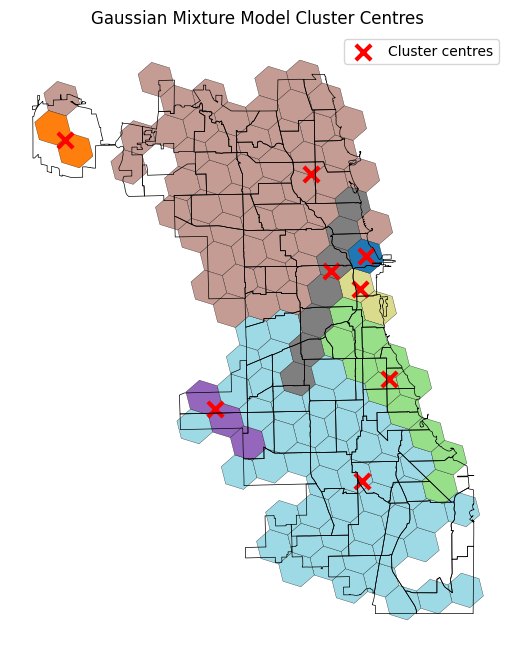

In [ ]:
means = gmm.means_

fig, ax = plt.subplots(figsize=(8, 8))

hotspot_gdf.plot(
    column="cluster",
    categorical=True,
    legend=False,
    cmap="tab20",
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
)

community_areas.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
)

ax.scatter(
    means[:, 0],
    means[:, 1],
    color="red",
    marker="x",
    s=120,
    linewidth=3,
    label="Cluster centres",
)

ax.legend()

ax.set_title("Gaussian Mixture Model Cluster Centres")
ax.set_axis_off()

plt.show()

In order to analyze the resulting clusters they are compared to the POI data from `chicago_pois_agg_7.csv`.

In [ ]:
hotspot_pois = hotspot_gdf.merge(
    pois_h3_7,
    left_on="h3_index_pickup_7",
    right_on="h3_index",
    how="left",
)

In [ ]:
from collections import Counter
pd.set_option("display.max_colwidth", None)

cluster_poi_summary = []

for cluster, group in hotspot_pois.groupby("cluster"):

    counter = Counter()

    for poi_types in group["poi_type_list"].dropna():
        counter.update(
            poi.strip()
            for poi in poi_types.split(",")
        )

    top5 = ", ".join(
        f"{poi} ({count})"
        for poi, count in counter.most_common(5)
    )

    cluster_poi_summary.append({
        "Cluster": cluster,
        "Top POI types": top5
    })

cluster_poi_summary = (
    pd.DataFrame(cluster_poi_summary)
    .sort_values("Cluster")
    .set_index("Cluster")
)

cluster_poi_summary

,Top POI types
Cluster,
0,"restaurant (309), cafe (112), clothes (106), fast_food (98), hotel (96)"
1,"fast_food (46), information (33), restaurant (28), ticket (28), newsagent (25)"
2,"restaurant (197), place_of_worship (169), school (128), fast_food (125), bicycle_rental (99)"
3,"fast_food (21), school (12), place_of_worship (12), restaurant (9), bank (7)"
4,"restaurant (1018), place_of_worship (766), fast_food (570), bar (429), school (422)"
5,"restaurant (434), fast_food (191), bar (139), bicycle_rental (126), cafe (118)"
6,"restaurant (239), fast_food (180), artwork (136), cafe (89), bicycle_rental (68)"
7,"place_of_worship (761), school (356), fast_food (271), bicycle_rental (221), convenience (190)"


To provide additional context for the identified hotspot clusters, the dominant point-of-interest (POI) categories within each cluster were examined. 

Cluster 1 represents O'Hare International Airport in the northwest of the city. This interpretation is supported by transport-related POIs such as ticket facilities, information services, and newsagents, reflecting the airport environment and its associated passenger traffic.

The compact cluster in the city centre (Cluster 0) coincides with Chicago's central business district. The dominant POI categories include restaurants, cafés, clothes shops, and hotels, indicating a dense commercial and tourism area with consistently high taxi demand.

The southwestern cluster (Cluster 3) corresponds to the area surrounding Midway Airport. Although the aggregated POI information is less distinctive than for O'Hare, the cluster location suggests that airport traffic is the primary driver of demand.

Clusters 2, 5, and 6 cover mixed-use urban areas with varying combinations of commercial, leisure, and neighbourhood amenities. In contrast, Clusters 4 and 7 represent larger residential parts of the city, where schools, places of worship, and local services dominate the POI composition. These broader clusters indicate that taxi demand outside the city centre is distributed across residential neighbourhoods rather than concentrated around individual activity centres.

Overall, the POI information provides qualitative support for the interpretation of the detected hotspots. Major transportation hubs and the central business district emerge as the strongest generators of taxi demand, while the remaining clusters represent broader residential and commercial areas across the city.

### 4.2 Kernel Density Estimation

While the Gaussian Mixture Model partitions the study area into discrete hotspot clusters, Kernel Density Estimation (KDE) provides a continuous representation of the spatial demand intensity. Each H3 cell contributes to the density surface according to its pickup demand, resulting in a smooth estimate of hotspot intensity across the city.

In [ ]:
X = hotspot_gdf[["x", "y"]].to_numpy()

kde = KernelDensity(
    bandwidth=0.015,
    kernel="gaussian",
)

kde.fit(
    X,
    sample_weight=hotspot_gdf["trip_count"]
)

hotspot_gdf["density"] = np.exp(
    kde.score_samples(X)
)

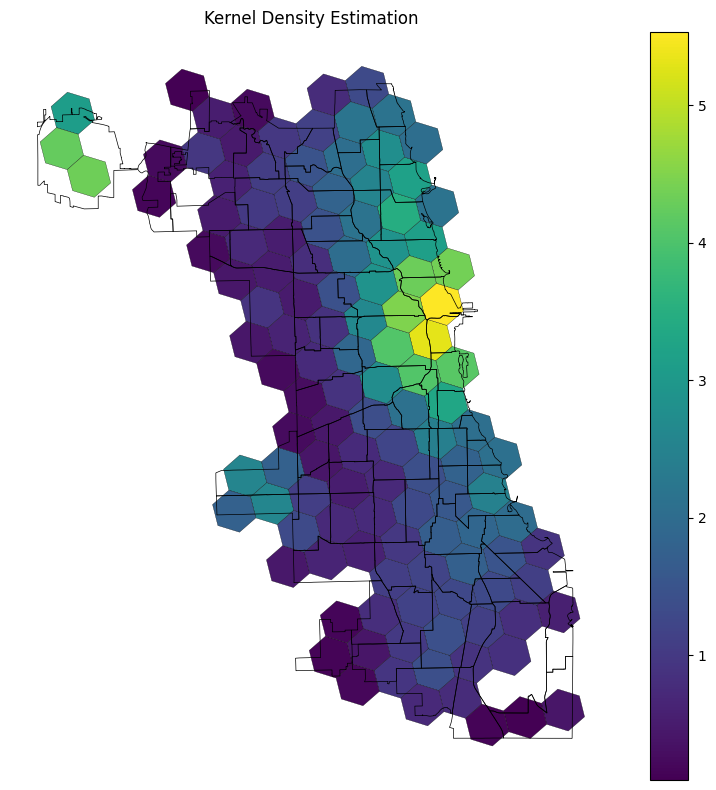

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

hotspot_gdf["log_density"] = np.log1p(hotspot_gdf["density"])

hotspot_gdf.plot(
    column="log_density",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
)

community_areas.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
)

ax.set_title("Kernel Density Estimation")
ax.set_axis_off()

plt.tight_layout()
plt.show()

Kernel Density Estimation confirms the same dominant demand centres identified by the Gaussian Mixture Model. The highest density occurs in the central business district, followed by O'Hare Airport. Compared to GMM, KDE provides a smooth representation of demand intensity rather than discrete hotspot boundaries.